In [1]:
from langgraph.graph import StateGraph , START,  END 
from typing import TypedDict 
from pydantic import BaseModel , Field


In [44]:
class InvestigateState(TypedDict):
    
    page_load_time_sec  : int 
    monthly_visitors: int 
    
    seo_score  : int 
    seo_impact : float
    traffic_growth : float
    average_score : float
    grade :  str
    


In [61]:
def calculate_load_score(state : InvestigateState):
    return {"seo_score": max(0, 100 - (state['page_load_time_sec'] * 10))}


def calculate_seo_impact(state : InvestigateState):
    # Check if seo_score exists in state, otherwise calculate it
    if 'seo_score' not in state or state['seo_score'] is None:
        seo_score = max(0, 100 - (state['page_load_time_sec'] * 10))
    else:
        seo_score = state['seo_score']
    
    impact = seo_score * 0.8
    return {'seo_impact': impact}

def calculate_traffic_growth(state : InvestigateState):
    traffic = state['monthly_visitors'] / 1000
    
    return {"traffic_growth" : traffic}

def final_report(state : InvestigateState):
    # Ensure all required values exist
    seo_score = state.get('seo_score', 0)
    traffic_growth = state.get('traffic_growth', 0)
    seo_impact = state.get('seo_impact', 0)
    
    average = (seo_score + traffic_growth + seo_impact) / 3 

    if average >= 70:
        grade = "A"
    elif average >= 40:
        grade = "B"
    else:
        grade = "C"

    return {
        "average_score": average,
        "grade": grade
    }


In [62]:
graph = StateGraph(InvestigateState)

graph.add_node("calculate_load_score" , calculate_load_score)
graph.add_node("calculate_seo_impact" , calculate_seo_impact)
graph.add_node("calculate_traffic_growth" ,calculate_traffic_growth)
graph.add_node("final_report" , final_report)

graph.add_edge(START , "calculate_load_score")
graph.add_edge(START , "calculate_seo_impact")
graph.add_edge(START ,"calculate_traffic_growth")

graph.add_edge("calculate_load_score" , "final_report")
graph.add_edge("calculate_seo_impact","final_report")
graph.add_edge("calculate_traffic_growth" , "final_report")

graph.add_edge("final_report" , END)

workflow = graph.compile()


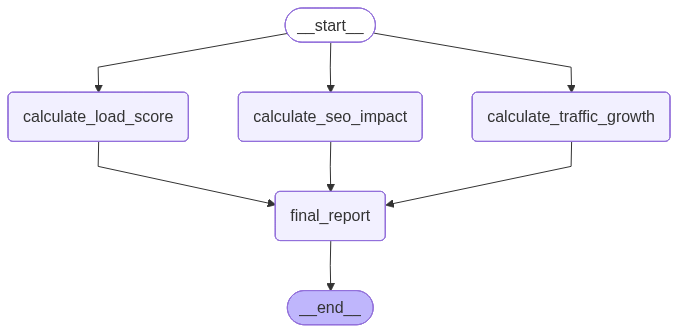

In [63]:
workflow


In [73]:
intial_state  = {
    "page_load_time_sec"  : 0.1 ,
    "monthly_visitors" :  200     
}

final_state = workflow.invoke(intial_state)


In [74]:
final_state


{'page_load_time_sec': 0.1,
 'monthly_visitors': 200,
 'seo_score': 99.0,
 'seo_impact': 79.2,
 'traffic_growth': 0.2,
 'average_score': 59.46666666666667,
 'grade': 'B'}